<div style="display: flex; flex-direction: column; align-items: center; text-align: center; font-family: 'Avenir Next LT Pro', sans-serif; padding: 56px 40px; background: linear-gradient(135deg, #0f172a 0%, #1e293b 55%, #0b1220 100%); border-radius: 18px; box-shadow: 0px 14px 30px rgba(0, 0, 0, 0.25); border: 1px solid rgba(148, 163, 184, 0.18); border-bottom: 5px solid #38bdf8;">
    <p style="margin: 0 0 12px 0; color: #7dd3fc; font-size: 18px; font-weight: 700; letter-spacing: 0.12em; text-transform: uppercase;">Python for Tech Leaders</p>
    <h1 style="font-size: 44px; font-weight: 800; color: #f8fafc; margin: 0; line-height: 1.15;">Machine Learning - Titanic</h1>
    <p style="font-size: 18px; color: #cbd5e1; max-width: 800px; line-height: 1.6; margin: 20px 0 0 0;">
        Será que é possivel prever quem iria sobreviver no titanic?
    </p>
</div>

## imports

In [1]:
# Importar bibliotecas

import scipy as sp
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, log_loss, classification_report
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pathlib import Path
# Ir buscar a localização deste ficheiro
dir = Path.cwd().parent
data_dir = dir / "data"
print(data_dir)

# Importar funções de visualização personalizadas
sys.path.append(str(dir / "src"))
from plot import plot_bar, plot_confusion_matrix, plot_hist, plot_corr_heatmap, plot_feature_importance, plot_logistic_curve, plot_svm_margins, plot_knn_boundaries

c:\Users\diogo\Desktop\python-for-tech-leaders\5. AI\data


# 1. Business Understanding

O naufrágio do **Titanic** é um dos mais infames da história.

A 15 de abril de 1912, durante a sua viagem inaugural, o RMS Titanic - amplamente considerado “inafundável” - afundou após colidir com um icebergue. Infelizmente, não havia botes salva-vidas suficientes para todos a bordo, o que resultou na morte de 1502 das 2224 pessoas entre passageiros e tripulação.

Embora a sobrevivência tenha tido algum fator de sorte, parece que certos grupos de pessoas tinham maior probabilidade de sobreviver do que outros.

Neste desafio, pedimos que construas um modelo preditivo para responder à questão: “Que tipo de pessoas tinham mais probabilidade de sobreviver?” utilizando dados dos passageiros (como nome, idade, género, classe socioeconómica, etc.).

# 2. Data Understanding

In [2]:
#Import the data
df_titanic = pd.read_csv(data_dir / "titanic.csv")
df_titanic_untouched = df_titanic.copy()

# Em vez de estarem na mesma pasta do notebook, podem usar o caminho absoluto do ficheiro

# Porquê .copy()? Porque queremos um objeto independente, não um apontador para df_titanic
# Assim, cria-se uma cópia independente de um objeto. Evita-se que alterações na cópia afetem o objeto original

# Ex.:
# >>> a = [1, 2]  # cria um objeto na memória que aponta para 1 e 2, e aponta a para ele
# >>> b = a       # aponta b para onde a aponta (porque a é um objeto mutável)
# >>> a[0] = 2    # altera o objeto para onde a aponta, direcionando o seu primeiro item para 2
# >>> a
# [2, 2]
# >>> b
# [2, 2]

In [3]:
df_titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

| Coluna        | Descrição |
|--------------|------------|
| **PassengerId** | Identificador único de cada passageiro. |
| **Survived** | Indica se o passageiro sobreviveu ao naufrágio. <br> **0** = Não sobreviveu <br> **1** = Sobreviveu |
| **Pclass** | Classe do passageiro. <br> **1** = Primeira classe <br> **2** = Segunda classe <br> **3** = Terceira classe |
| **Name** | Nome do passageiro. |
| **Sex** | Gênero do passageiro. |
| **Age** | Idade do passageiro. |
| **SibSp** | Número de irmãos(ãs) e/ou cônjuge a bordo. |
| **Parch** | Número de pais e/ou filhos a bordo. |
| **Ticket** | Número do bilhete do passageiro. |
| **Fare** | Tarifa paga pelo passageiro. |
| **Cabin** | Número da cabine do passageiro. |
| **Embarked** | Porto de embarque. <br> **C** = Cherbourg <br> **Q** = Queenstown <br> **S** = Southampton |

In [4]:
# Check data structure
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Verificar os tipos de dados e obter mais informações
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


| Tipo de Variável | O que é? (Simplificado) | Variáveis |
| :--- | :--- | :--- |
| **Categóricas** | **Etiquetas**. Nomes ou grupos sem ordem matemática. | `Survived`, `Sex`, `Embarked`, `Ticket`, `Cabin`, `Name` |
| **Ordinais** | **Rankings**. Categorias que têm uma hierarquia clara. | `Pclass` |
| **Contínuas** | **Medições**. Podem ter casas decimais (vírgulas). | `Age`, `Fare` |
| **Discretas** | **Contagens**. Números inteiros (não há "meio" passageiro). | `SibSp`, `Parch`, `PassengerId` |

In [6]:
# Calculamos a soma de nulos
nulos = df_titanic.isnull().sum()

# Filtramos apenas os maiores que 0, ordenamos e transformamos em Tabela (DataFrame)
nulos[nulos > 0].sort_values(ascending=False).to_frame(name='Qtd Nulos')

,Qtd Nulos
Cabin,687
Age,177
Embarked,2


# 3. Data Preparation (simplificado)

In [7]:
# Looking for abnormal outliers
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Começamos por eliminar as variáveis que não fazem realmente sentido nos nossos modelos de previsão

df_titanic.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace = True)

# Porquê eliminar estas colunas?
# PassengerId: Apenas um identificador único, sem poder preditivo
# Name: Nomes são únicos e não generalizáveis (a não ser que extraíssemos títulos como "Mr.", "Mrs.", etc.)
# Ticket: Número do bilhete é muito específico e caótico para ser útil
# Cabin: Tem demasiados valores em falta (≈80%) e é complexa de preencher 

## 2.1. Tratamentos dos nulos

### 2.1.1. Imputação (mediana)

Age mean:  29.69911764705882
Age median:  28.0


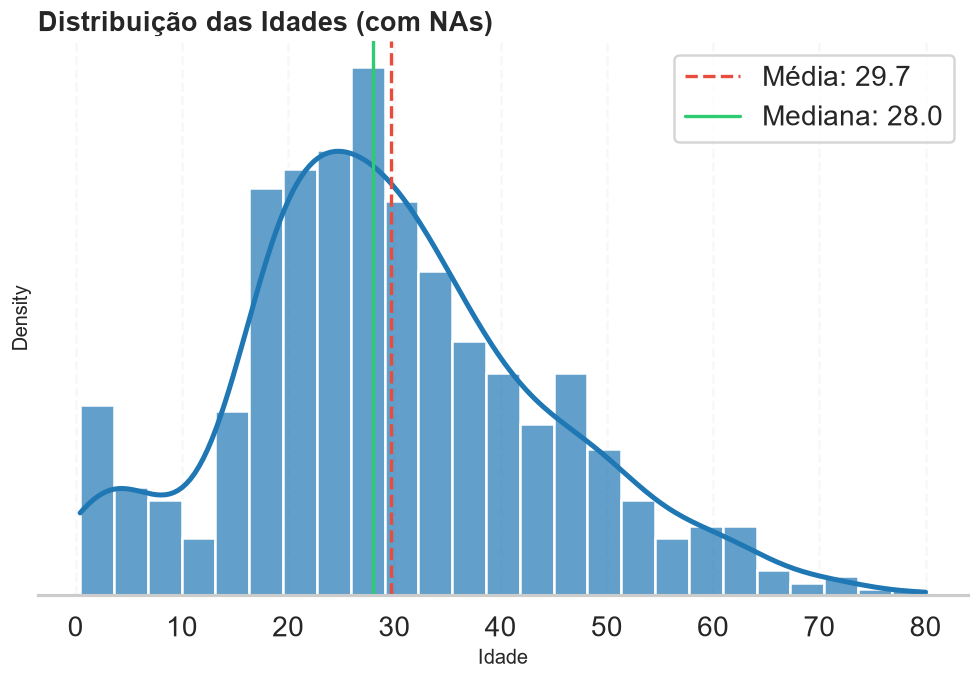

In [9]:
# Limpar valores em falta para a variável 'Age'

# Cuidado, não podes obter um histograma se tiver valores em falta (NA)!

# Distribuição normal
plot_hist(
    df_titanic['Age'].dropna(),
    bins=25,
    kde=True,
    color="#1f77b4",
    title="Distribuição das Idades (com NAs)",
    xlabel="Idade"
)
print ("Age mean: ", df_titanic['Age'].mean())
print ("Age median: ", df_titanic['Age'].median())
plt.show()

Podemos observar no gráfico que a distribuição apresenta uma cauda alongada à direita. Como não segue uma distribuição normal, esta cauda pode puxar a média para a direita, distorcendo-a, afastando-a do centro da maioria dos dados. Por esse motivo, será mais adequado utilizar a Mediana em vez da Média para preencher os valores em falta (NA), uma vez que a mediana é menos sensível a valores extremos e fornece uma medida de tendência central mais robusta para esta distribuição assimétrica.

Age mean:  29.36158249158249
Age median:  28.0


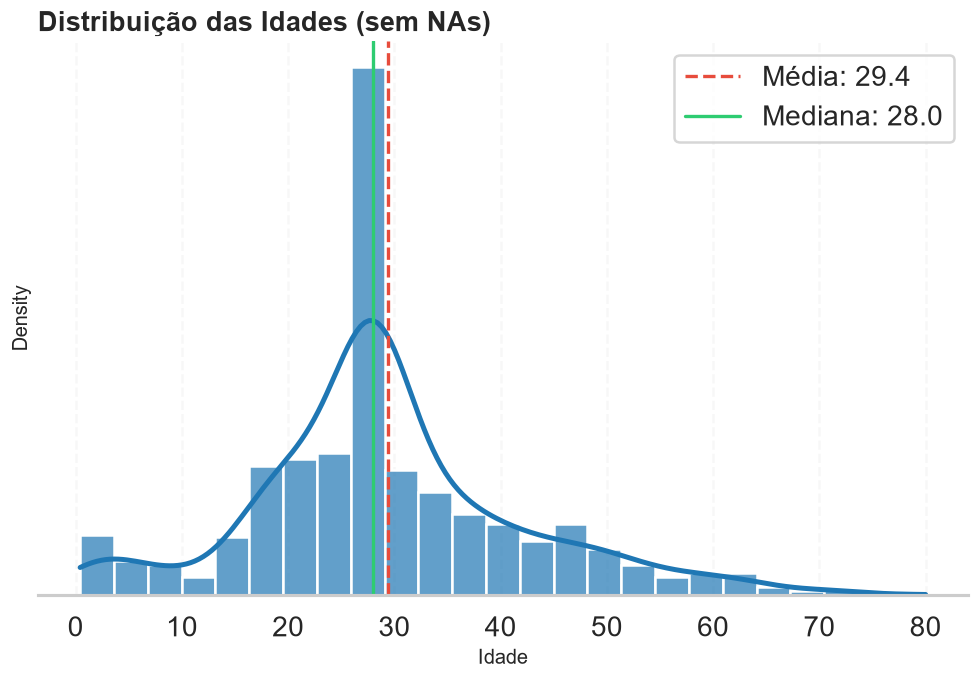

In [10]:
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

# Distribuição normal
plot_hist(
    df_titanic['Age'],
    bins=25,
    kde=True,
    color="#1f77b4",
    title="Distribuição das Idades (sem NAs)",
    xlabel="Idade"
)
print ("Age mean: ", df_titanic['Age'].mean())
print ("Age median: ", df_titanic['Age'].median())
plt.show()

### 2.1.2. Apagar os dados

**Linhas**

In [11]:
# Calcular a percentagem de perda
qtd_nulos = df_titanic['Embarked'].isnull().sum()
percentagem = df_titanic['Embarked'].isnull().mean() * 100

print(f"A remover {qtd_nulos} linhas com 'Embarked' nulo.")
print(f"Isto representa uma perda de {percentagem:.2f}% dos dados.")

# O teu código de limpeza mantém-se aqui:
df_titanic.dropna(subset=['Embarked'], inplace=True)

A remover 2 linhas com 'Embarked' nulo.
Isto representa uma perda de 0.22% dos dados.


**Coluna**

In [12]:
# Justificação: Calculamos a percentagem de nulos (aprox. 77%)
perc_cabin = df_titanic['Cabin'].isnull().mean() * 100
print(f"A coluna 'Cabin' tem {perc_cabin:.1f}% de dados em falta. Vamos removê-la.")

# Ação: 'drop' com columns=[] elimina a COLUNA inteira
df_titanic.drop(columns=['Cabin'], inplace=True)

A coluna 'Cabin' tem 77.3% de dados em falta. Vamos removê-la.


## 2.2. Feature Engineering

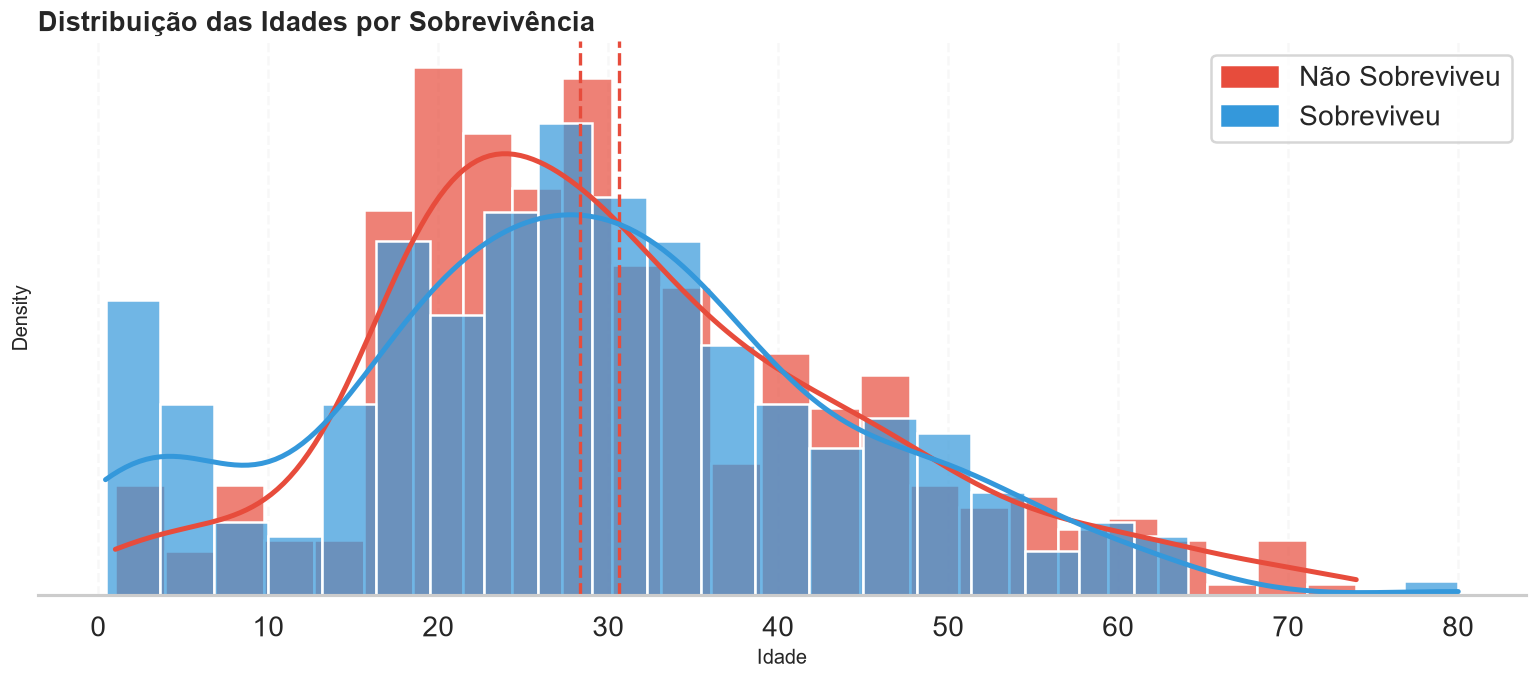

In [13]:
# Data Visualization

# Distribuição das idades dos passageiros que sobreviveram (azul) vs os que não sobreviveram (vermelho) - juntos
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(16, 6))
plot_hist(
    df_titanic_untouched[df_titanic_untouched.Survived == 0]["Age"],
    bins=25, kde=True, color="#e74c3c", title="Distribuição das Idades por Sobrevivência", xlabel="Idade", ax=ax
)
plot_hist(
    df_titanic_untouched[df_titanic_untouched.Survived == 1]["Age"],
    bins=25, kde=True, color="#3498db", xlabel="Idade", ax=ax
)
red_patch = mpatches.Patch(color="#e74c3c", label="Não Sobreviveu")
blue_patch = mpatches.Patch(color="#3498db", label="Sobreviveu")
ax.legend(handles=[red_patch, blue_patch])
plt.show()

- A prioridade dada às crianças é visível nos dados.
- Pessoas entre 20-30 anos tiveram melhor capacidade de sobrevivência.
- Os passageiros mais velhos foram claramente prejudicados na evacuação.

As decisões humanas durante o naufrágio refletem-se nas distribuições de sobrevivência por idade!

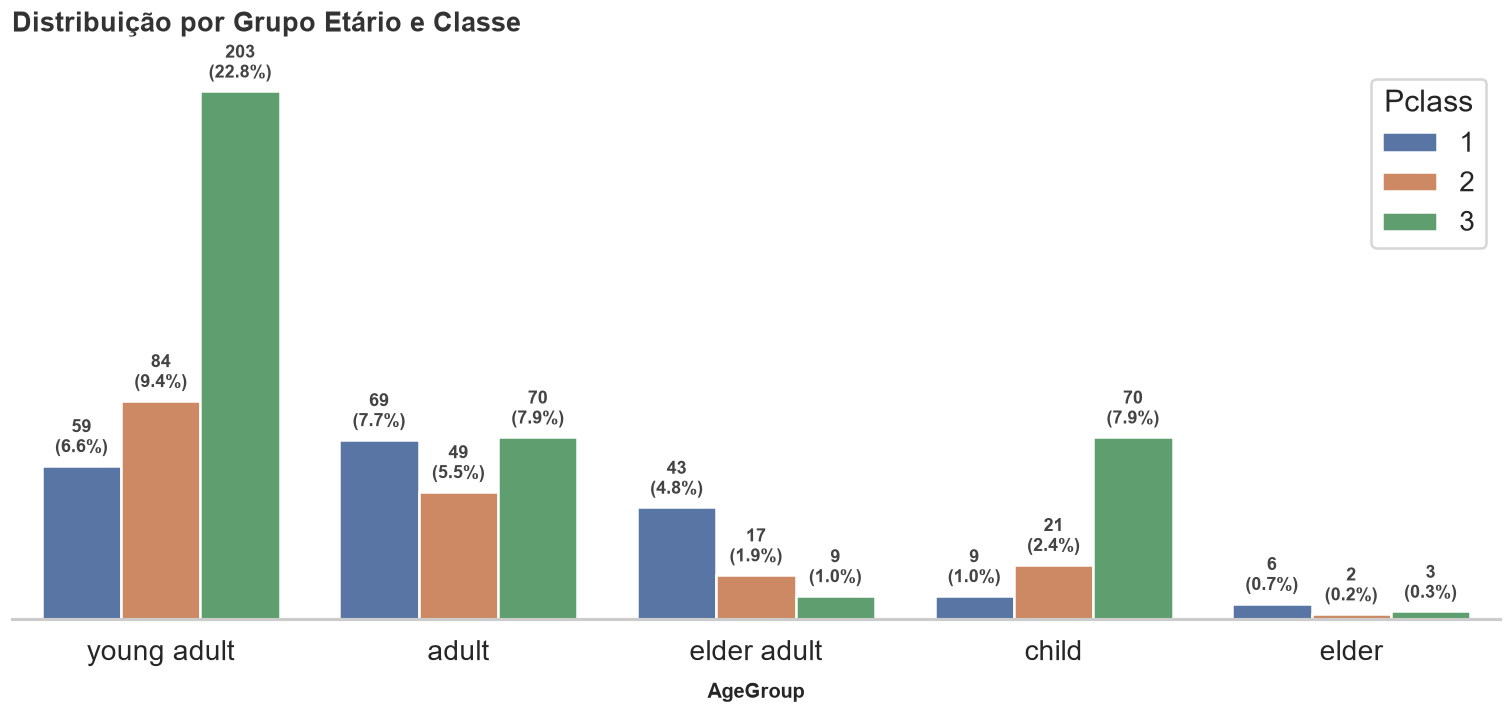

In [14]:
# Análise do Gráfico de Distribuição por Grupos Etários ('Age') e Classe Social ('PClass')
# Explicar a alta mortalidade entre os 16 anos e os 30 anos?

# A discretização é a transformação de variáveis contínuas (como Age e Fare) em variáveis categóricas ou ordinais. 

def ageDiscretization (row):
    if row['Age'] <= 16:
        return 'child'
    elif row['Age'] > 16 and row['Age'] <= 32:
        return 'young adult'
    elif row['Age'] > 32 and row['Age'] <= 48:
        return 'adult'
    elif row['Age'] > 48 and row['Age'] <= 64:
        return 'elder adult'
    elif row['Age'] > 64:
        return 'elder'

plot_bar(
    data=df_titanic_untouched.assign(AgeGroup=df_titanic_untouched.apply(ageDiscretization, axis=1)),
    x="AgeGroup",
    hue="Pclass",
    title="Distribuição por Grupo Etário e Classe",
    figsize=(16, 6),
    palette="deep"
)
plt.show()

A alta mortalidade entre os 16-32 anos não é necessariamente porque esta faixa etária foi "escolhida" para morrer, mas porque:

- Eram a maioria da população do Titanic
- Eram maioritariamente da 3ª classe (com menor acesso aos botes)
- Homens jovens foram provavelmente os menos prioritários no salvamento

In [15]:
# df_titanic['Fare_Cut'] = pd.qcut(df_titanic['Fare'], 4)
# df_titanic.groupby(['Fare_Cut'], as_index=False)['Survived'].mean()

# Porquê usar quartis?
# Os quartis dividem os dados ordenados em x partes iguais. Cada grupo tem aproximadamente o mesmo número de passageiros. 
# Isto garante que não criamos grupos vazios ou desbalanceados.

In [16]:
# Discretização por Quartis para 'Fare' e Lógica para 'Age'

def fareDiscretization (row):
    if row['Fare'] <= 7.91:
        return 0
    elif row['Fare'] > 7.91 and row['Fare'] <= 14.454:
        return 1
    elif row['Fare'] > 14.454 and row['Fare'] <= 31:
        return 2
    elif row['Fare'] > 31:
        return 3
    
df_titanic['Age_Group'] = df_titanic.apply(ageDiscretization, axis = 1)
df_titanic['Fare_Group'] = df_titanic.apply(fareDiscretization, axis = 1)

df_titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_Group,Fare_Group
0,0,3,male,22.0,1,0,7.2500,S,young adult,0
1,1,1,female,38.0,1,0,71.2833,C,adult,3
2,1,3,female,26.0,0,0,7.9250,S,young adult,1
3,1,1,female,35.0,1,0,53.1000,S,adult,3
4,0,3,male,35.0,0,0,8.0500,S,adult,1


In [17]:
# Inclui também as variáveis não numéricas ('Sex', 'Embarked' e 'Age_Group'), recorrendo a one-hot encoding
# One-hot-encoding: Transforma variáveis categóricas em variáveis binárias (0/1)

df_titanic_encoded = pd.get_dummies(df_titanic, columns=["Sex", "Embarked"], prefix=["Sex", "Embarked"], drop_first=True)
df_titanic_encoded['Age_Group'] = df_titanic_encoded['Age_Group'].map({
    'child': 0,
    'young adult': 1, 
    'adult': 2,
    'elder adult': 3,
    'elder': 4
})

## Modelos de machine learning trabalham com números, não com texto. One-hot encoding é a forma mais comum de lidar com categorias.

## 2.3. Matriz de Correlação

Uma matriz de correlação é uma tabela que exibe os coeficientes de correlação entre vários pares de variáveis, mostrando a força e a direção de suas relações. Os coeficientes de correlação são medidas numéricas que quantificam a força e a direção dessa relação. Aqui usamos o coeficiente de Pearson. 

Valores próximos de 1 ou -1 indicam **correlação forte**, enquanto valores próximos de **0** indicam quase nenhuma correlação.

Em data science, usamos este recurso para selecionar ou excluir variáveis nos modelos com base nas suas relações. Variáveis altamente correlacionadas podem causar multicolinearidade em modelos de regressão, o que pode distorcer os resultados. Ao identificar estas correlações, reduzimos a redundância e melhoramos o desempenho do modelo. **!!**

In [18]:
df_titanic_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,Age_Group,Fare_Group,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,True,False,True
1,1,1,38.0,1,0,71.2833,2,3,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,True
3,1,1,35.0,1,0,53.1000,2,3,False,False,True
4,0,3,35.0,0,0,8.0500,2,1,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1,1,True,False,True
887,1,1,19.0,0,0,30.0000,1,2,False,False,True
888,0,3,28.0,1,2,23.4500,1,2,False,False,True
889,1,1,26.0,0,0,30.0000,1,2,True,False,False


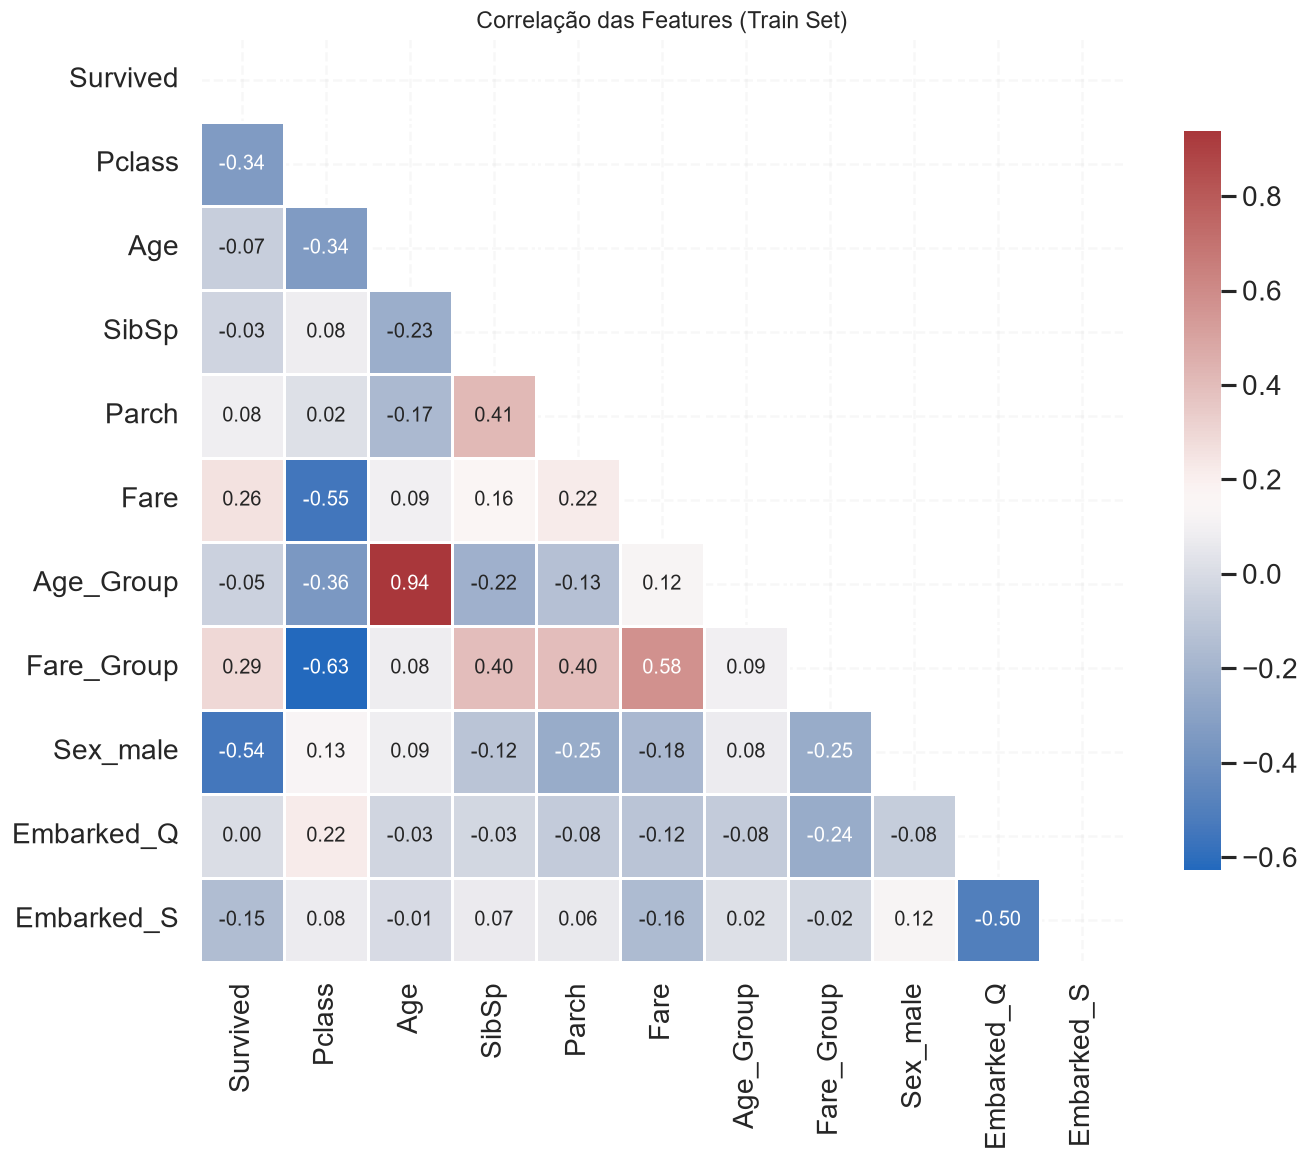

In [19]:
plot_corr_heatmap(
    df_titanic_encoded,
    title="Correlação das Features (Train Set)",
    figsize=(13, 10),
    cmap="vlag",
    annot=True
)
plt.show()

**Conclusões para Feature Selection:**
- Variáveis mais importantes: Sexo, Classe, e Preço do Bilhete
- Multicolinearidade: Algumas variáveis estão altamente correlacionadas entre si (ex: Age vs Age_Group), pelo que podemos eliminar uma delas nos modelos

In [20]:
# Feature Selection
cols_delete = ['SibSp','Age','Fare', 'Age_Group']

if all(col in df_titanic_encoded.columns for col in cols_delete):
    df_titanic_encoded.drop(columns=cols_delete, inplace=True)

Através da nossa análise de seleção de características, selecionámos as seguintes 6 variáveis:

- Pclass 
- Age_Group 
- Parch 
- Fare_Group 
- Sex
- Embarked 

In [21]:
df_titanic_encoded.columns

Index(['Survived', 'Pclass', 'Parch', 'Fare_Group', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

# 4. Modeling

In [22]:
# Dicionário para guardar resultados dos modelos
model_results = {}

# 1. Definir Features (X) e Target (y)
# X (Maiúsculo): Matriz de características (Features)
# y (minúsculo): Vetor alvo (Target/Label)
X = df_titanic_encoded.drop(columns=['Survived'])
y = df_titanic_encoded['Survived']

# 2. Dividir os dados
# test_size=0.3: Reserva 30% para testar o modelo no final
# random_state=21: Garante que a divisão é sempre a mesma (reprodutível)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21)

# 3. Output Visualmente Organizado
print(f"--- Conjunto de TREINO (70%) ---")
print(f"X_train: {X_train.shape}  (Linhas, Colunas)")
print(f"y_train: {y_train.shape}     (Respostas)")
print(f"\n--- Conjunto de TESTE (30%) ---")
print(f"X_test:  {X_test.shape}  (Linhas, Colunas)")
print(f"y_test:  {y_test.shape}     (Respostas)")

--- Conjunto de TREINO (70%) ---
X_train: (622, 6)  (Linhas, Colunas)
y_train: (622,)     (Respostas)

--- Conjunto de TESTE (30%) ---
X_test:  (267, 6)  (Linhas, Colunas)
y_test:  (267,)     (Respostas)


Se treinássemos e testássemos com os mesmos dados, o modelo poderia memorizar os dados em vez de aprender padrões.
Os dados de teste funcionam como "dados nunca vistos" pelo modelo.

## Regressão Logística (Logistic Regression)

![Logistic Regression Curve](https://aimlsite.wordpress.com/wp-content/uploads/2017/08/logisticregresssion.png)

Ao contrário do que o nome sugere, este modelo não serve para prever valores numéricos (como o preço de uma casa), mas sim para **classificar** (neste caso: *Sobreviveu* ou *Não Sobreviveu*).

Imaginem que o modelo funciona como um sistema de pontuação:
1.  Ele atribui "pontos" a cada passageiro baseando-se nas suas características (**Idade**, **Sexo**, **Classe**).
2.  A seguir, transforma essa pontuação matemática numa **probabilidade entre 0% e 100%**.

A linha azul curva (chamada sigmoide) representa a "certeza" do modelo:
* **Quanto mais para a direita (Topo):** Maior a certeza de que o passageiro **Sobreviveu** (probabilidade aproxima-se de 1.0).
* **Quanto mais para a esquerda (Fundo):** Maior a certeza de que **Não Sobreviveu** (probabilidade aproxima-se de 0.0).
* **A Fronteira de Decisão:** O modelo define um limite nos **50% (0.5)**. Se a probabilidade calculada for superior a este valor, o modelo "carimba" a previsão final como **Sobreviveu**.

                precision    recall  f1-score   support

    Sobreviveu       0.68      0.65      0.66        82
Não Sobreviveu       0.85      0.86      0.86       185

      accuracy                           0.80       267
     macro avg       0.76      0.76      0.76       267
  weighted avg       0.80      0.80      0.80       267



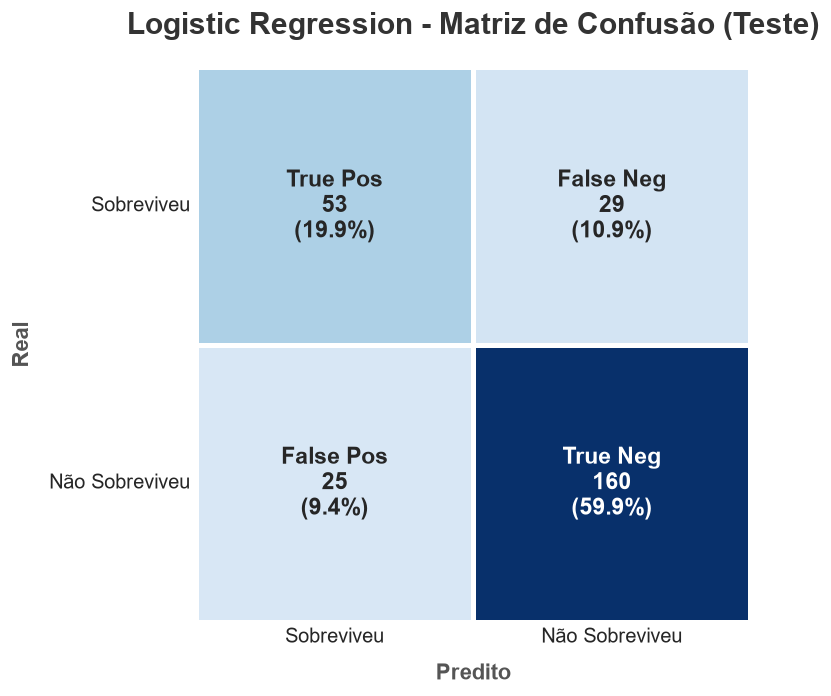

In [23]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
Y_pred = logreg.predict(X_test)

acc_logreg = accuracy_score(y_test, Y_pred)
report_logreg = classification_report(y_test, Y_pred, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0], output_dict=True)
model_results["Logistic Regression"] = {
    "accuracy": acc_logreg,
    "precision": report_logreg["Sobreviveu"]["precision"],
    "recall": report_logreg["Sobreviveu"]["recall"],
    "f1-score": report_logreg["Sobreviveu"]["f1-score"]
}

plot_confusion_matrix(y_test, Y_pred, title="Logistic Regression - Matriz de Confusão (Teste)")
print(classification_report(y_test, Y_pred, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0]))

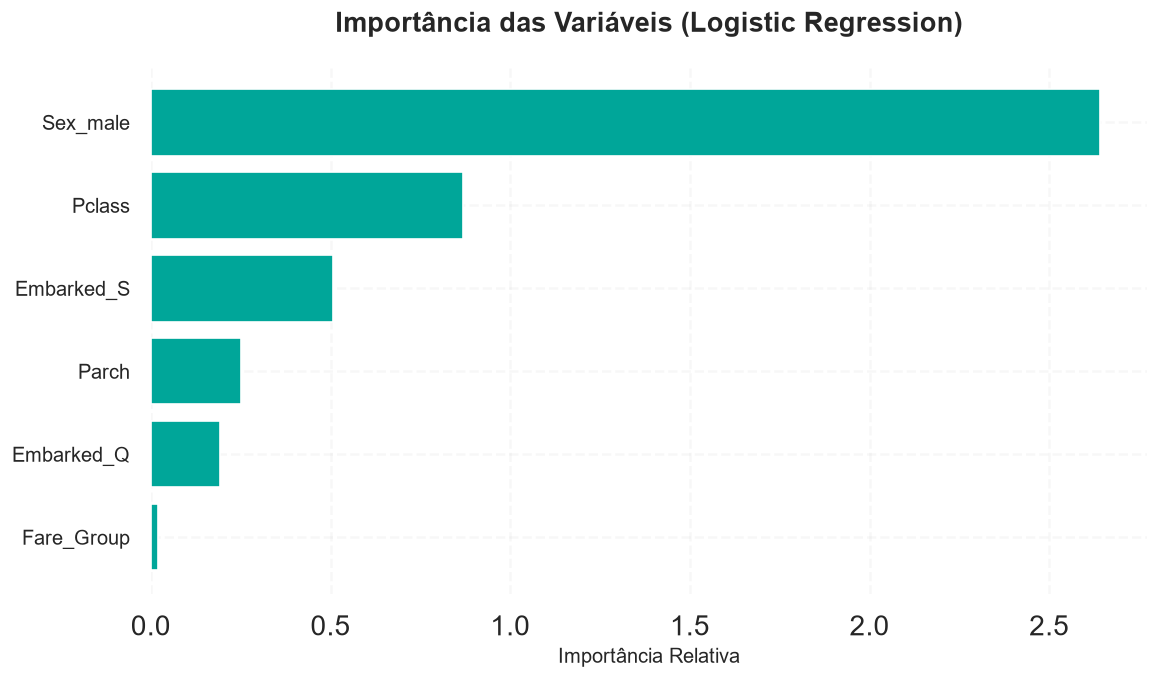

In [24]:
plot_feature_importance(logreg, X.columns, title="Importância das Variáveis (Logistic Regression)")
plt.show()

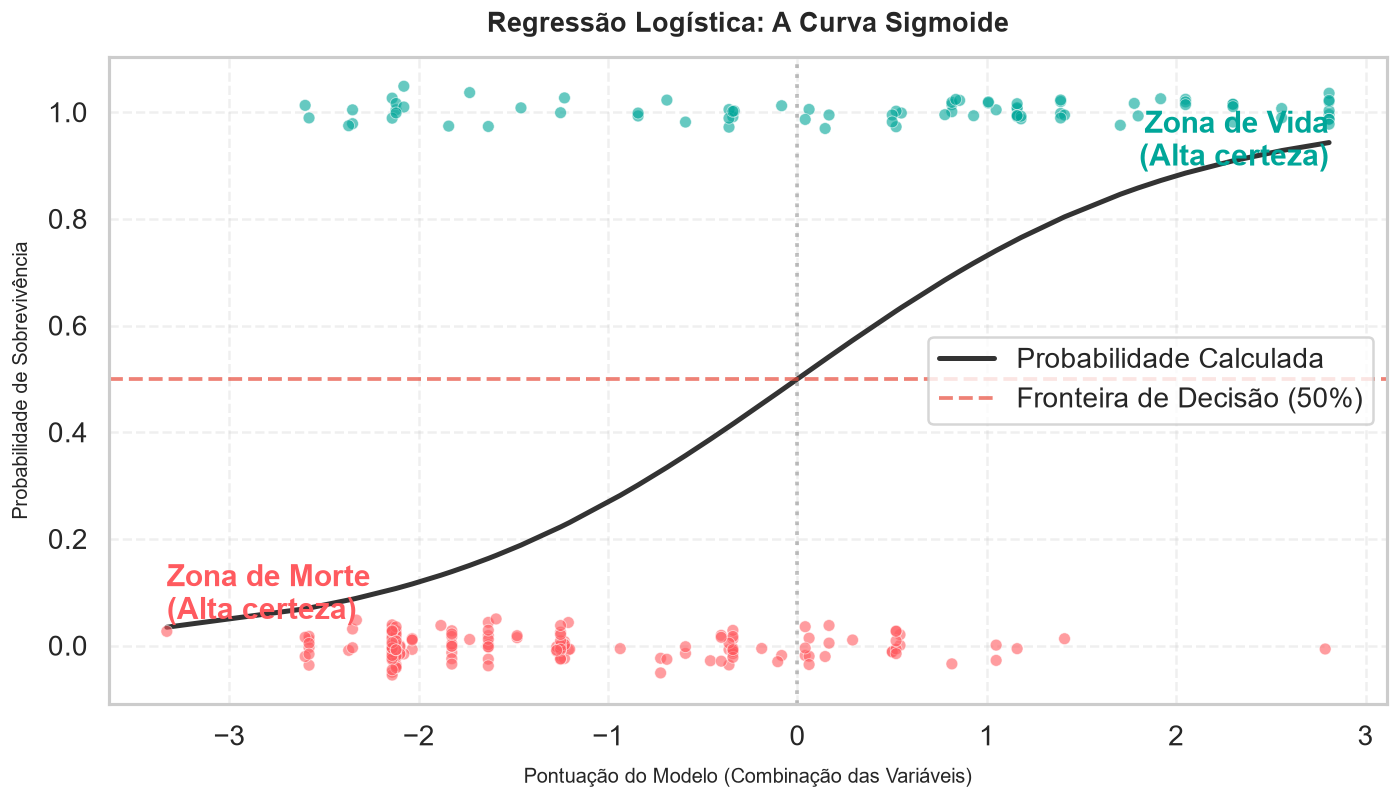

In [25]:
plot_logistic_curve(logreg, X_test, y_test)

Este gráfico compara a **previsão do modelo** (linha preta) com a **realidade** (pontos coloridos).

**O Eixo X (A Pontuação)**
Representa a combinação de todas as variáveis (Idade + Sexo + Classe).
* **Esquerda:** Perfil de alto risco (ex: Homem, 3ª Classe).
* **Direita:** Perfil de segurança (ex: Mulher, 1ª Classe).

**A Linha Preta (A Confiança)**
Mostra a probabilidade calculada pelo modelo.
* **Abaixo de 50%:** O modelo prevê "Não Sobreviveu".
* **Acima de 50%:** O modelo prevê "Sobreviveu".

**Os Pontos (A Realidade)**
* 🔴 **Vermelhos:** Pessoas que realmente **faleceram**.
* 🟢 **Verdes:** Pessoas que realmente **sobreviveram**.

---

**Análise dos Resultados:**
* **Nos Extremos (Sucesso):** O modelo funciona muito bem. A maioria dos pontos vermelhos está na esquerda (fundo) e os verdes na direita (topo).
* **No Centro (Incerteza):** Perto do meio, as cores misturam-se.
    * 🔴 **Vermelhos à direita:** Falsos Positivos (O modelo achava que sobreviviam, mas morreram).
    * 🟢 **Verdes à esquerda:** Falsos Negativos (O modelo achava que morriam, mas salvaram-se "por milagre").

## SVM (Support Vector Machine)

![Suport Vector Machine](https://towardsdatascience.com/wp-content/uploads/2023/10/1bXlp7LVAPhIay-Pk0MxdlA.png)

O objetivo do SVM não é apenas separar os sobreviventes dos não-sobreviventes com uma linha qualquer. Ele tenta encontrar a "estrada" mais larga possível que separe os dois grupos com a máxima margem de segurança.

Imaginem um campo de batalha: o SVM tenta desenhar a fronteira (trincheira) que mantenha os dois exércitos o mais afastados possível um do outro para evitar erros. Pontos difíceis de classificar definem onde passa essa fronteira.

                precision    recall  f1-score   support

    Sobreviveu       0.75      0.60      0.67        82
Não Sobreviveu       0.84      0.91      0.87       185

      accuracy                           0.82       267
     macro avg       0.80      0.76      0.77       267
  weighted avg       0.81      0.82      0.81       267



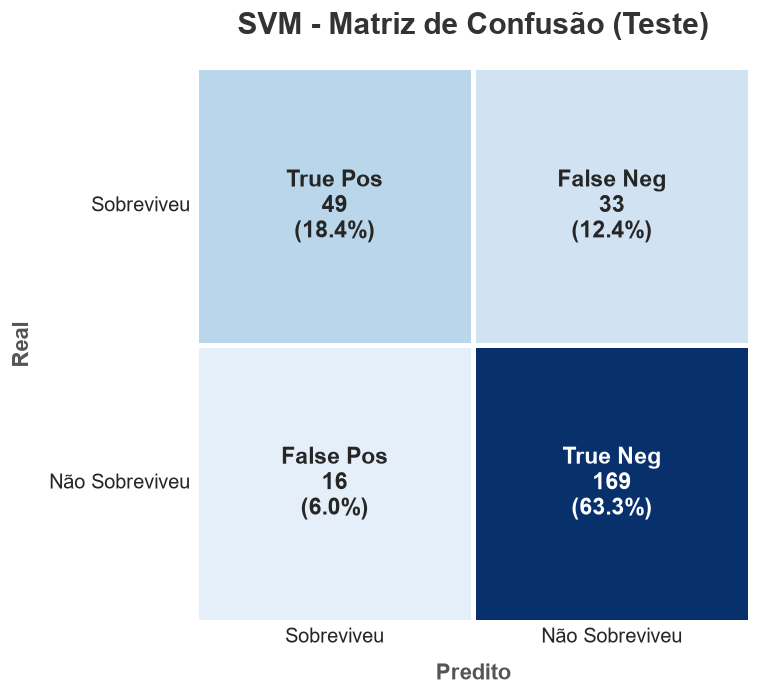

In [26]:
svc = SVC()
svc.fit(X_train, y_train)
Y_pred = svc.predict(X_test)

acc_svc = accuracy_score(y_test, Y_pred)
report_svc = classification_report(y_test, Y_pred, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0], output_dict=True)
model_results["SVM"] = {
    "accuracy": acc_svc,
    "precision": report_svc["Sobreviveu"]["precision"],
    "recall": report_svc["Sobreviveu"]["recall"],
    "f1-score": report_svc["Sobreviveu"]["f1-score"]
}

print(classification_report(y_test, Y_pred, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0]))
plot_confusion_matrix(y_test, Y_pred, title="SVM - Matriz de Confusão (Teste)")
plt.show()

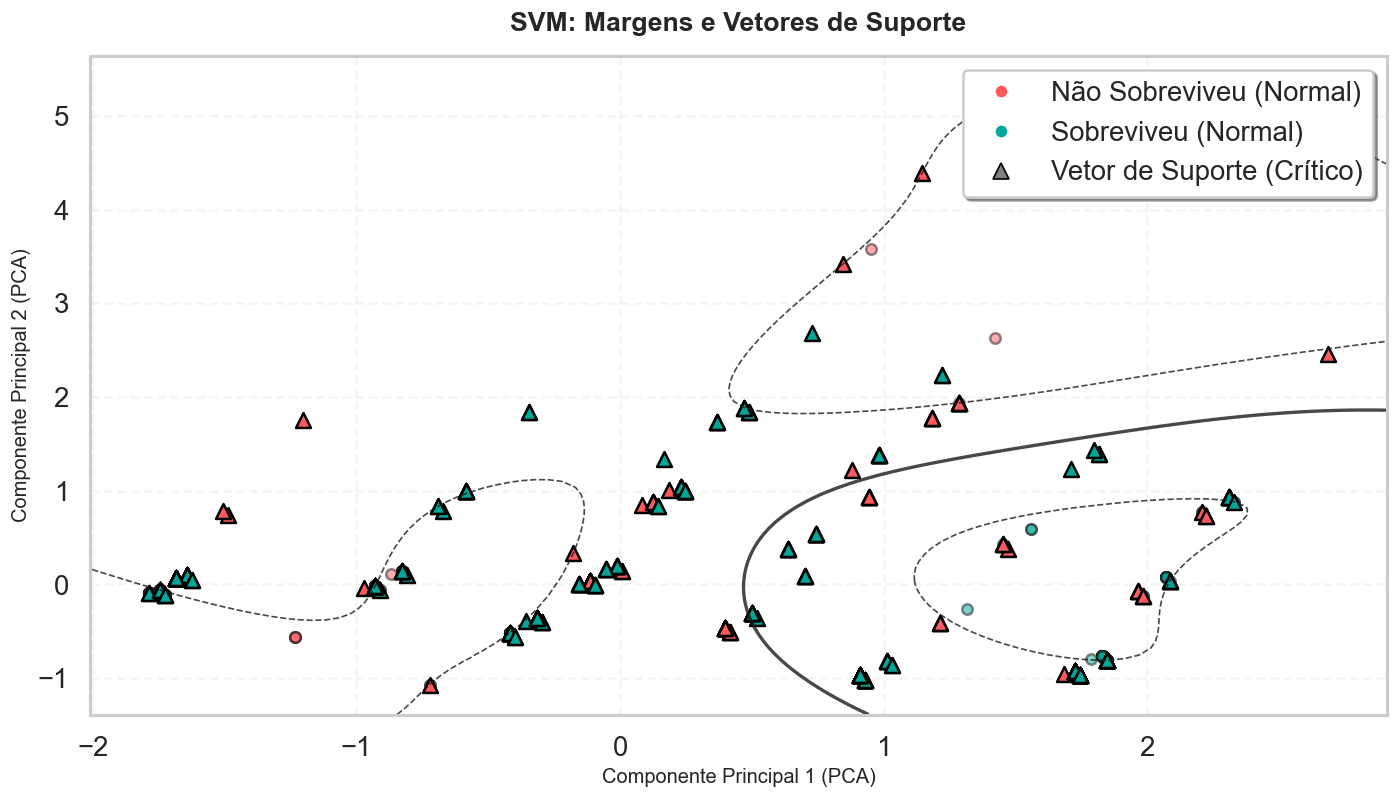

In [27]:
plot_svm_margins(svc, X_train, y_train)

Este gráfico representa a "estrada" que o SVM criou para separar quem sobreviveu de quem não sobreviveu, utilizando **PCA** para reduzir todas as variáveis a apenas duas dimensões.

**A Fronteira e as Margens**
* **Linha Sólida:** É a divisão principal. De um lado o modelo prevê "Sobreviveu", do outro "Não Sobreviveu".
* **Linhas Tracejadas:** Representam as margens de segurança. O SVM tenta manter estas linhas o mais afastadas possível para garantir que a separação é robusta.

**Os Vetores de Suporte (Pontos Circulados)**
* São os passageiros mais importantes para este modelo. 
* Representam os casos mais difíceis e limítrofes. O SVM foca-se exclusivamente nestes pontos para desenhar a fronteira, ignorando os passageiros que estão longe e são "fáceis" de classificar.

---

**Análise dos Resultados:**
* O modelo criou uma fronteira complexa (não é uma linha reta), o que indica que usou um **Kernel** (provavelmente RBF) para detetar padrões não-lineares nos dados.
* Nota-se que muitos pontos estão dentro das margens (entre as linhas tracejadas). Isto mostra que o Titanic é um problema com muita sobreposição, onde características semelhantes podem levar a resultados diferentes devido à natureza imprevisível do evento.

## Random Forests

![Random Forest](https://media.geeksforgeeks.org/wp-content/uploads/20240701170624/Random-Forest-Algorithm.webp)

Uma única Árvore de Decisão faz perguntas simples ("É homem?", "Pagou muito?"). O problema é que uma árvore sozinha erra muito.
O Random Forest cria 100 árvores diferentes, onde cada uma estuda apenas uma parte dos dados. No final, faz-se uma votação.

Se 70 árvores dizem "Sobreviveu" e 30 dizem "Morreu", a decisão final da floresta é Sobreviveu. É um modelo muito robusto porque a opinião do grupo corrige os erros individuais.

                precision    recall  f1-score   support

    Sobreviveu       0.81      0.61      0.69        82
Não Sobreviveu       0.84      0.94      0.89       185

      accuracy                           0.84       267
     macro avg       0.83      0.77      0.79       267
  weighted avg       0.83      0.84      0.83       267



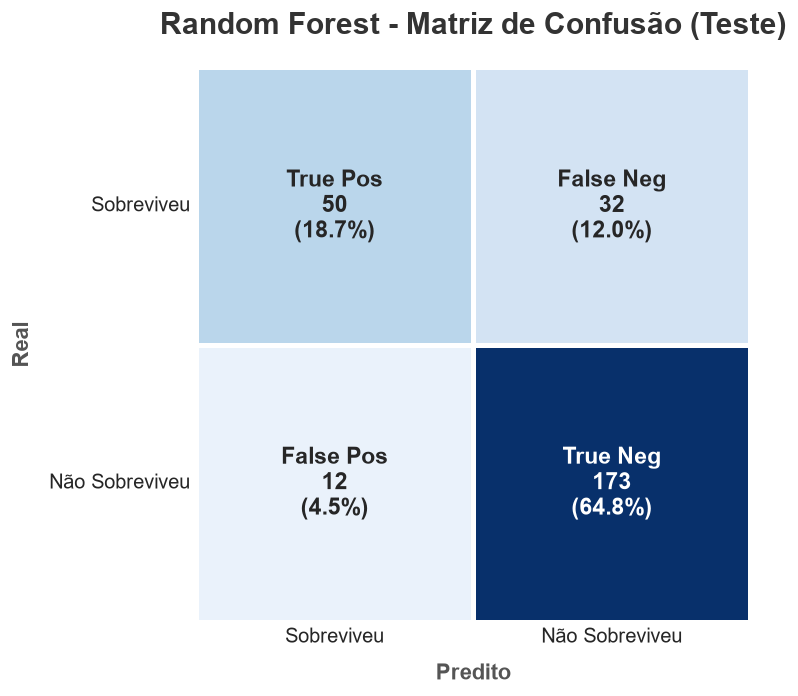

In [27]:
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)
Y_pred = random_forest.predict(X_test)

acc_rf = accuracy_score(y_test, Y_pred)
report_rf = classification_report(y_test, Y_pred, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0], output_dict=True)
model_results["Random Forest"] = {
    "accuracy": acc_rf,
    "precision": report_rf["Sobreviveu"]["precision"],
    "recall": report_rf["Sobreviveu"]["recall"],
    "f1-score": report_rf["Sobreviveu"]["f1-score"]
}

print(classification_report(y_test, Y_pred, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0]))
plot_confusion_matrix(y_test, Y_pred, title="Random Forest - Matriz de Confusão (Teste)")
plt.show()

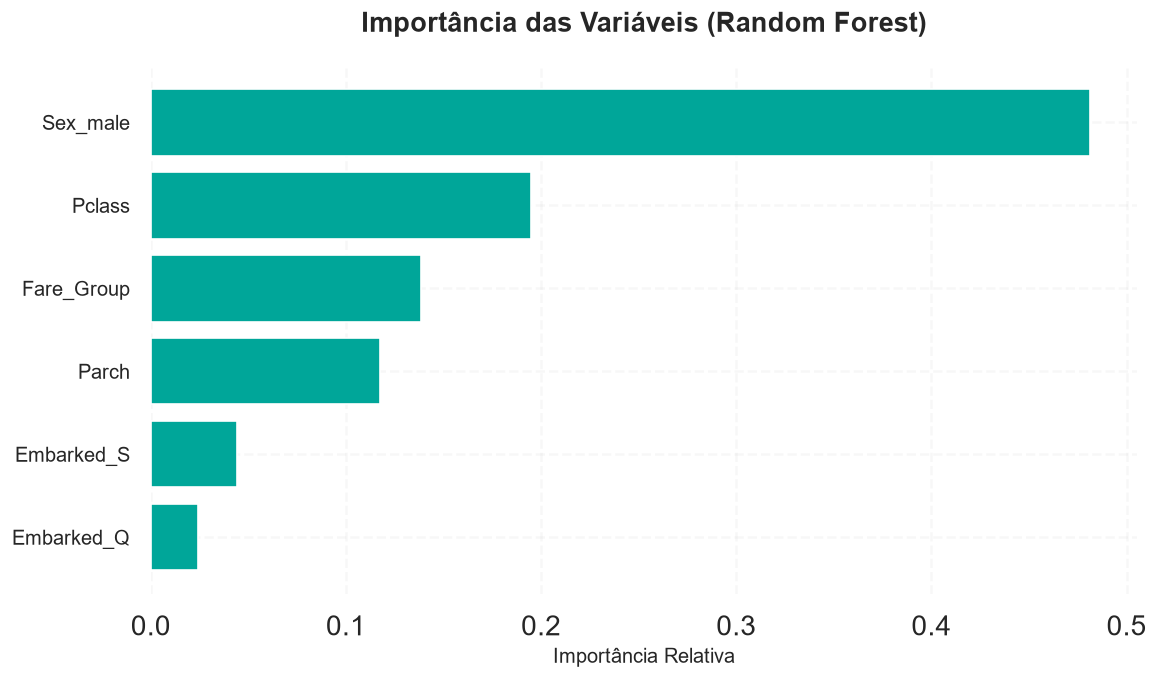

In [28]:
plot_feature_importance(random_forest, X.columns, title="Importância das Variáveis (Random Forest)")
plt.show()

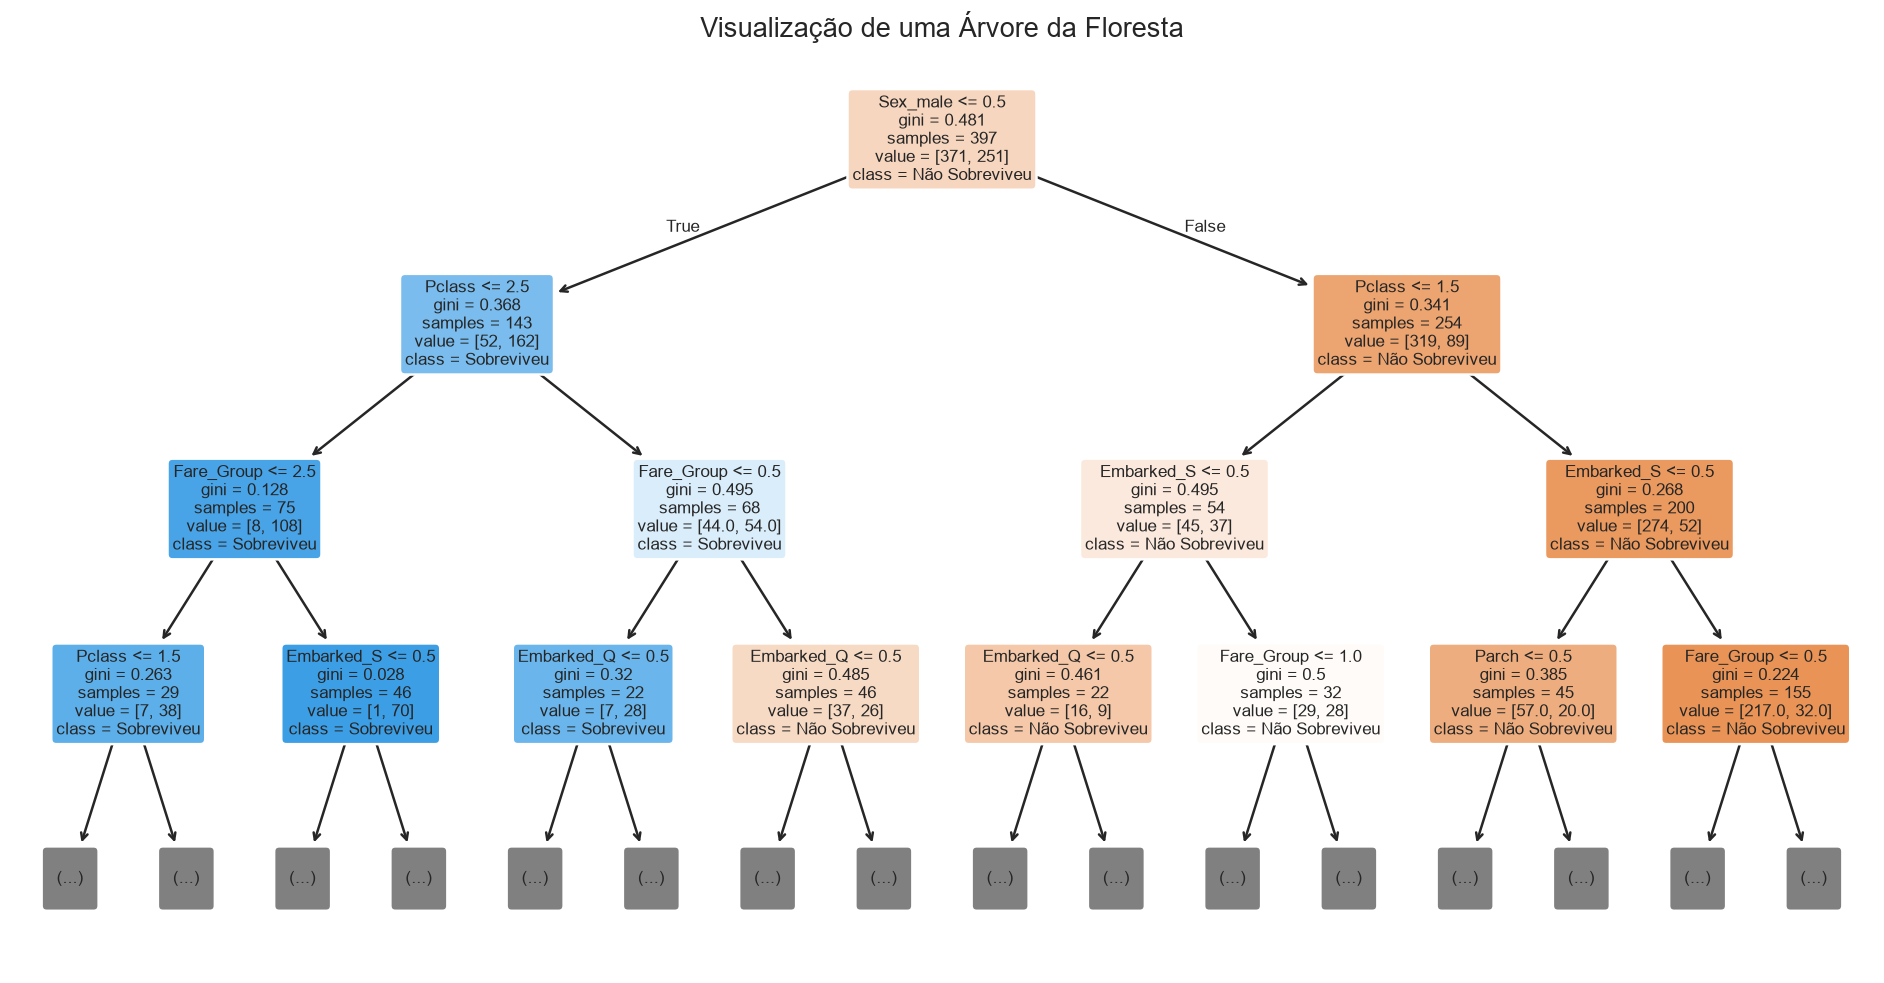

In [29]:
from sklearn.tree import plot_tree

# Vamos buscar a primeira árvore da floresta (index 0)
# Podes mudar para estimators_[5] ou outros para ver árvores diferentes
plt.figure(figsize=(20, 10))

plot_tree(
    random_forest.estimators_[0], 
    feature_names=X.columns,
    class_names=["Não Sobreviveu", "Sobreviveu"],
    filled=True, 
    rounded=True,
    max_depth=3,  # Limita a profundidade para ser legível
    fontsize=10
)

plt.title("Visualização de uma Árvore da Floresta", fontsize=16)
plt.show()

## K-Nearest Neighbours (KNN)

Este é o algoritmo mais intuitivo de todos. Para decidir se um novo passageiro sobrevive, o modelo olha para os passageiros mais parecidos com ele (os "vizinhos") que já conhecemos.

Se escolhermos 3 vizinhos (K=3) e 2 deles sobreviveram, o modelo assume que este novo passageiro também sobreviveu. É pura vizinhança.

![KNN](https://towardsdatascience.com/wp-content/uploads/2021/11/13SwcOCUyVdGauhHrHvOaLA.png)

                precision    recall  f1-score   support

    Sobreviveu       0.76      0.65      0.70        82
Não Sobreviveu       0.85      0.91      0.88       185

      accuracy                           0.83       267
     macro avg       0.80      0.78      0.79       267
  weighted avg       0.82      0.83      0.82       267



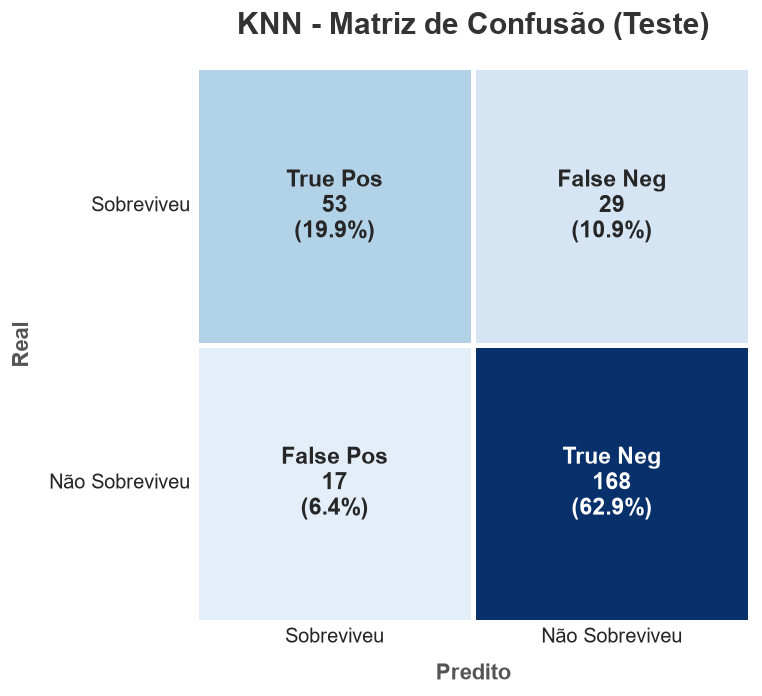

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train_scaled, y_train)

# Fazer previsões nos dados de TESTE
Y_pred = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, Y_pred)
report_knn = classification_report(y_test, Y_pred, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0], output_dict=True)
model_results["KNN"] = {
    "accuracy": acc_knn,
    "precision": report_knn["Sobreviveu"]["precision"],
    "recall": report_knn["Sobreviveu"]["recall"],
    "f1-score": report_knn["Sobreviveu"]["f1-score"]
}

print(classification_report(y_test, Y_pred, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0]))
plot_confusion_matrix(y_test, Y_pred, title="KNN - Matriz de Confusão (Teste)")
plt.show()

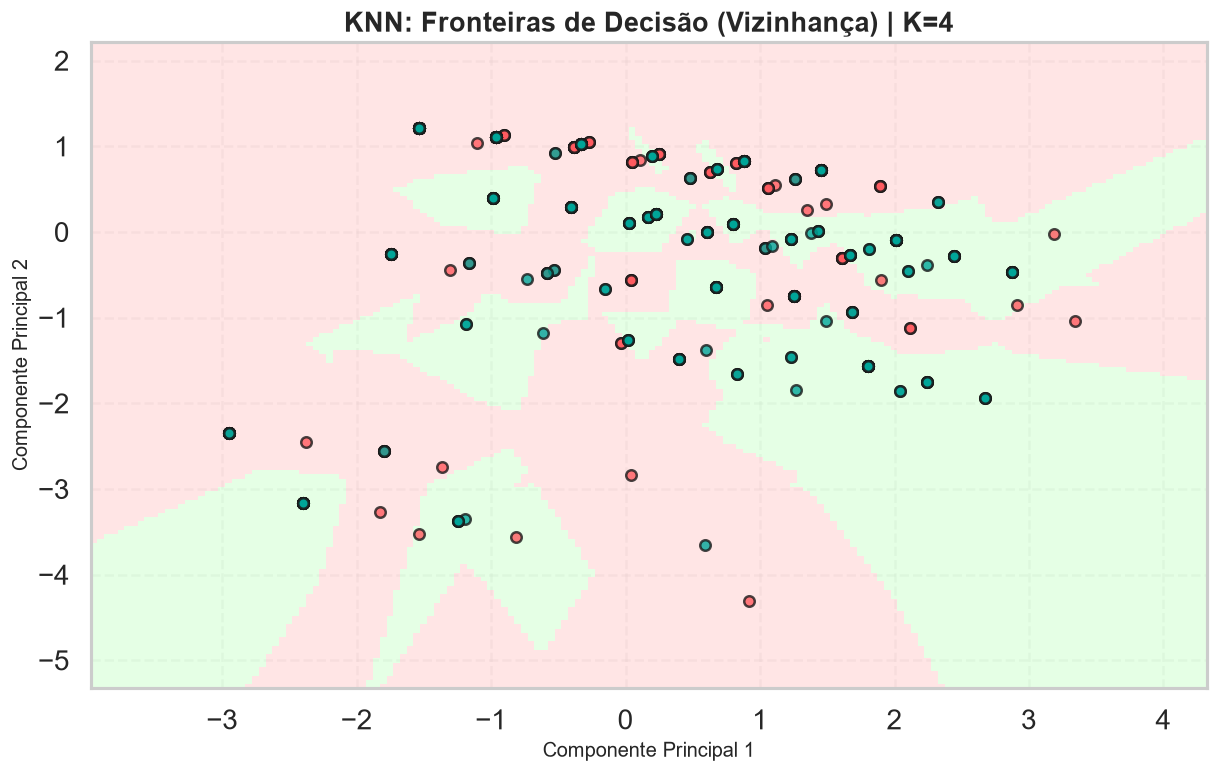

In [31]:
# Importante: O KNN EXIGE dados escalados para o gráfico fazer sentido
plot_knn_boundaries(knn, X_train_scaled, y_train)

O gráfico de **Fronteiras de Decisão** permite visualizar como o KNN "vota" em cada região do mapa:

* **Zonas Coloridas (Fundo):** Representam o território dominado por cada classe. Se um novo passageiro "aterrar" na zona verde, o modelo classifica-o automaticamente como Sobrevivente.
* **A Natureza do Modelo:** Ao contrário da Regressão Logística (que é uma linha reta), o KNN cria fronteiras mais irregulares e orgânicas. Ele adapta-se localmente à posição dos passageiros.

---

**🔎 Análise dos Resultados:**
Com **K=4**, o modelo tenta encontrar um equilíbrio. 
* Se as zonas estiverem muito "fragmentadas" (como pequenas ilhas), o modelo pode estar a sofrer de *overfitting* (a tentar decorar casos específicos). 
* Se as zonas forem suaves e contínuas, o modelo capturou bem a tendência geral de vizinhança entre os passageiros do Titanic.

### Será que sofre de overfitting? 

![Fitting](https://datahacker.rs/wp-content/uploads/2021/11/Picture3.jpg)

--- RELATÓRIO DE TREINO ---
                precision    recall  f1-score   support

    Sobreviveu       0.80      0.75      0.77       258
Não Sobreviveu       0.83      0.86      0.85       364

      accuracy                           0.82       622
     macro avg       0.81      0.81      0.81       622
  weighted avg       0.82      0.82      0.82       622



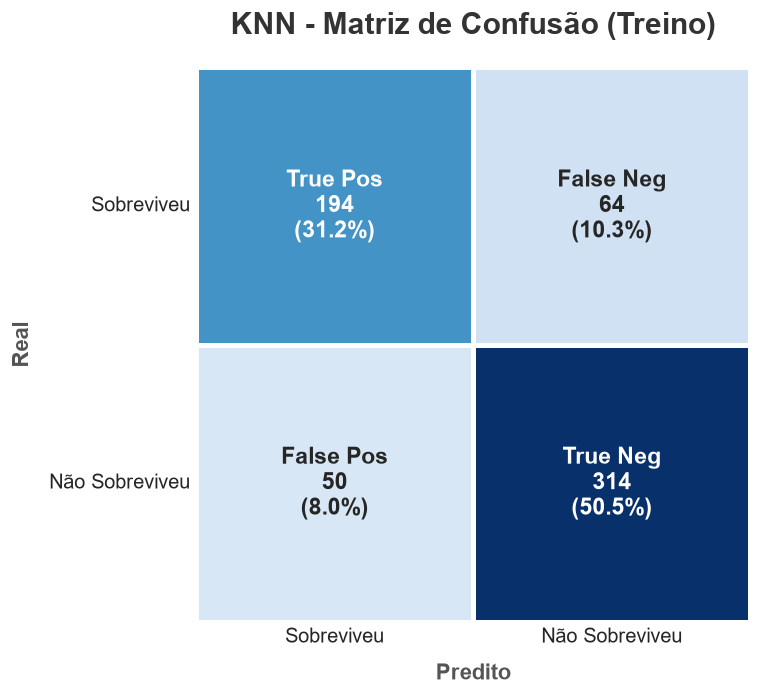

In [32]:
# --- ALTERAÇÃO AQUI ---
# Fazer previsões nos dados de TREINO (usamos X_train_scaled em vez de X_test_scaled)
Y_pred_train = knn.predict(X_train_scaled)

# Cálculo da acurácia e relatório para o Treino
acc_knn_train = accuracy_score(y_train, Y_pred_train)
report_knn_train = classification_report(y_train, Y_pred_train, target_names=["Sobreviveu", "Não Sobreviveu"], labels=[1, 0])

print("--- RELATÓRIO DE TREINO ---")
print(report_knn_train)

# Plot da Matriz de Confusão para o Treino
plot_confusion_matrix(y_train, Y_pred_train, title="KNN - Matriz de Confusão (Treino)")
plt.show()

# 5. Evaluation

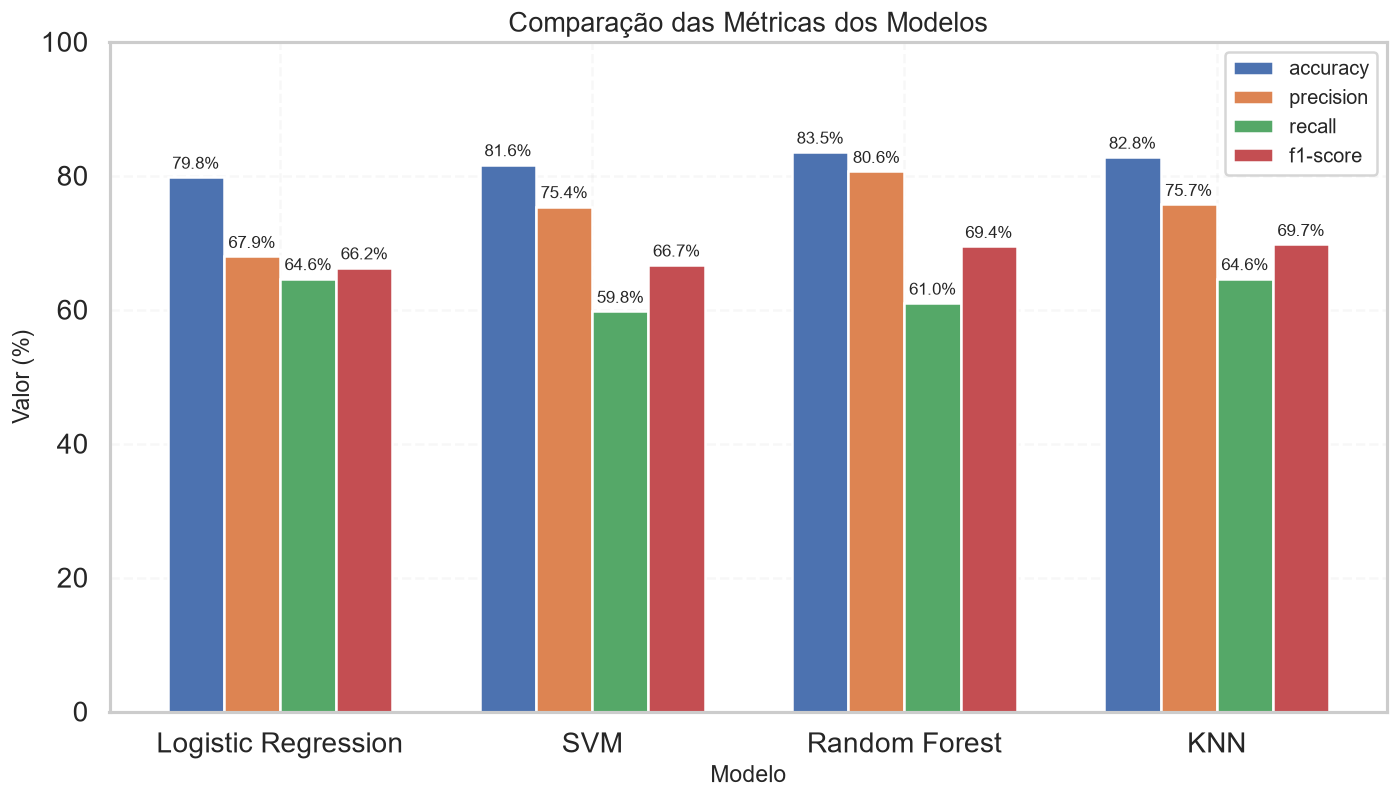

In [33]:
# --- Comparação das Métricas dos Modelos ---

metrics = ["accuracy", "precision", "recall", "f1-score"]
model_names = list(model_results.keys())
metric_values = {metric: [model_results[model][metric]*100 for model in model_names] for metric in metrics}

plt.figure(figsize=(12, 7))
bar_width = 0.18
x = np.arange(len(model_names))

for i, metric in enumerate(metrics):
    plt.bar(x + i*bar_width, metric_values[metric], width=bar_width, label=metric)

plt.title("Comparação das Métricas dos Modelos", fontsize=16)
plt.ylabel("Valor (%)", fontsize=14)
plt.ylim(0, 100)
plt.xlabel("Modelo", fontsize=14)
plt.xticks(x + bar_width*1.5, model_names)
plt.legend(fontsize=12)

# Adicionar valores acima das barras
for i, metric in enumerate(metrics):
    for j, value in enumerate(metric_values[metric]):
        plt.annotate(f'{value:.1f}%',
                     xy=(x[j] + i*bar_width, value),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

❓ Análise Comparativa dos Modelos

1. **Qual o modelo que apresenta a maior eficácia global ?**
2. **Qual dos modelos é mais confiável ao prever um sobrevivente ?**
3. **Qual dos modelos é o mais sensível a identificar todos os sobreviventes reais ?**
4. **Qual seria o modelo escolhido para aplicação num cenário real?**

A **Acurácia (Accuracy)** é a métrica mais intuitiva: indica a percentagem total de previsões corretas em relação ao total de passageiros. Mede a eficácia global do modelo.

$$Accuracy = \frac{TP + FN}{TP + FN + FP + FN}$$

A **Precisão (Precision)** responde à pergunta: *"De todos os passageiros que o modelo previu como Sobreviventes, quantos realmente sobreviveram?"*. Mede a confiança das previsões positivas, onde uma precisão alta significa poucos "alarmes falsos" (Falsos Positivos).

$$Precision = \frac{TP}{TP + FP}$$

A **Sensibilidade (Recall)** responde à pergunta: *"De todos os passageiros que realmente sobreviveram, quantos é que o modelo conseguiu encontrar?"*. Mede a capacidade de detetar a classe de interesse, onde um recall alto significa que poucos sobreviventes reais foram ignorados (Falsos Negativos).

$$Recall = \frac{TP}{TP + FN}$$



O **F1-Score** é uma média harmónica entre a Precisão e o Recall. É a métrica ideal quando se procura um equilíbrio entre as duas, sendo a mais indicada para comparar modelos quando existe um ligeiro desequilíbrio entre as classes.

$$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$